In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [2]:
# %load_ext cuml.accel

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from tqdm import tqdm
from time import time, sleep
from threadpoolctl import threadpool_limits

## -- Machine Learning --
if torch.cuda.is_available():
    import cupy as cp
    from cuml.neighbors import KNeighborsClassifier
    from cuml.linear_model import LogisticRegression
else:
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.linear_model import LogisticRegression

from sklearn.neural_network import MLPClassifier

from sklearn.calibration import CalibrationDisplay
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.metrics import roc_auc_score, log_loss, RocCurveDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, TargetEncoder as skTE

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, MissingIndicator, SimpleImputer

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --

PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e9/"
    submission = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/"
    orig = pd.read_csv(ORIG_PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submission = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID     = "id"
TARGET = 'Will_Buy_EV'

obj = train.select_dtypes(include=["object", "category"]).columns.tolist()

cat_cols  = [c for c in obj if c not in [TARGET, ID]]
num_cols  = [c for c in train.columns if c not in cat_cols+[TARGET, ID]]
base_cols = cat_cols + num_cols

train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
orig[TARGET]  = orig[TARGET].map({'No': 0, 'Yes': 1})

FEATURES = [c for c in train.columns if c not in [ID, TARGET]]

orig = orig[FEATURES+[TARGET]]
print("Total Features:", len(FEATURES))

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(num_cols)}")
print(f"Total Cats: {len(cat_cols)}")
print(f"Total base: {len(base_cols)}")

Total Features: 13
Train shape: (668665, 15)
Test shape: (286571, 14)
Orig shape: (10000, 14)

Total Nums: 7
Total Cats: 6
Total base: 13


In [6]:
for c in num_cols:
    orig[c] = orig[c].fillna(orig[c].median())

print(orig.isna().sum())

Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64


In [7]:
n_unique = train[base_cols].nunique().sort_values()
n_unique

Home_Charging_Possible             2
Subsidy_Available                  2
City_Type                          3
Gender                             3
Range_Anxiety_Level                3
Current_Car_Type                   4
Number_of_Cars_Owned               4
Environmental_Concern_Level        5
Charging_Stations_Near_Home       15
Charging_Stations_Near_Work       20
Age                               45
Daily_Commute_km                 805
Annual_Income_USD              13214
dtype: int64

In [8]:
def get_class_weights(y):
    """
    y: Current y_labels -> array_like or series
    """
    weights_ = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return weights_

def get_sample_weights(y, y_true):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    """
    classes_ = np.unique(y_true)
    weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
    class_weights = dict(zip(classes_, weights_))
    return np.array([class_weights[label] for label in y])

print("- Helper Functions Ready -")

- Helper Functions Ready -


# FEATURE ENGINEERING

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [10]:
def original_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc="original_augmenting"):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [11]:
# ## -- Cyclic encoding --
# CYCLICS = []

# for col in ['MonthlyCharges', 'TotalCharges']:
#     for p in [12, 30]:
#         n_s = f'{col}_sin_{p}'
#         n_c = f'{col}_cos_{p}'
#         train[n_s] = np.sin(2 * np.pi * train[col] / p).astype('float32')
#         train[n_c] = np.cos(2 * np.pi * train[col] / p).astype('float32')

#         test[n_s] = np.sin(2 * np.pi * test[col] / p).astype('float32')
#         test[n_c] = np.cos(2 * np.pi * test[col] / p).astype('float32')

#         orig[n_s] = np.sin(2 * np.pi * orig[col] / p).astype('float32')
#         orig[n_c] = np.cos(2 * np.pi * orig[col] / p).astype('float32')

#         CYCLICS += [n_s, n_c]

# print(f"Cylcic Features created: {len(CYCLICS)}")
# train[CYCLICS].head(3)

In [12]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# orig_aggs = ["mean", "count"]

# train, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     features=base_cols,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# test, _ = orig_TE_data_propagate(
#     orig,
#     test,
#     features=base_cols,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# train[orig_cols][:10].T

In [13]:
# poly_feats = []

# for col in ['bmi', 'LapTime_Delta']:
#     for x in [2]:
#         if x == 2:
#             sqr_n = f"_squared_{col}"
#             train[sqr_n] = train[col] ** 2
#             test[sqr_n]  = test[col] ** 2
#             orig[sqr_n]  = orig[col] ** 2
#             poly_feats.append(sqr_n)
#         elif x == 3:
#             cub_n = f"_cubed_{col}"
#             train[cub_n] = train[col] ** 3
#             test[cub_n]  = test[col] ** 3
#             orig[cub_n]  = orig[col] ** 3
#             poly_feats.append(cub_n)


# for col in ['TyreLife', 'RaceProgress', 'Cumulative_Degradation', 'LapTime (s)']:
#     for x in [3]:
#         if x == 2:
#             sqrd_n = f"_squared_{col}"
#             train[sqrd_n] = train[col] ** 2
#             test[sqrd_n]  = test[col] ** 2
#             orig[sqrd_n]  = orig[col] ** 2
#             poly_feats.append(sqrd_n)
#         elif x == 3:
#             cub_n = f"_cubed_{col}"
#             train[cub_n] = train[col] ** 3
#             test[cub_n]  = test[col] ** 3
#             orig[cub_n]  = orig[col] ** 3
#             poly_feats.append(cub_n)
#         else:
#             sqrt_n = f"_sqroot_{col}"
#             train[sqrt_n] = np.sqrt(train[col])
#             test[sqrt_n]  = np.sqrt(test[col])
#             orig[sqrt_n]  = np.sqrt(orig[col])
#             poly_feats.append(sqrt_n)
            
# poly_feats

In [14]:
# def poly_features(df_1, columns, formula=None):
#     df = df_1.copy()
#     poly_feats = []
    
#     print(f'Creating {formula} poly features... ', end='')
#     for col in columns:
#         if formula == 'sqrd':
#             sqrd_n = f"_squared_{col}"
#             df[sqrd_n] = df[col] ** 2
#             poly_feats.append(sqrd_n)
#         elif formula == 'cube':
#             cub_n = f"_cubed_{col}"
#             df[cub_n] = df[col] ** 3
#             poly_feats.append(cub_n)
#         elif formula == 'sqrt':
#             sqrt_n = f"_sqrt_{col}"
#             df[sqrt_n] = np.sqrt(df[col])
#             poly_feats.append(sqrt_n)

#     print(f'{len(poly_feats)} complete!')
            
#     return df, poly_feats

In [15]:
# squared_features = ['sleep_duration', 'heart_rate', 'bmi', 'exercise_duration', 'water_intake']
# train, sqrd_ = poly_features(train, squared_features, formula='sqrd')
# test, sqrd_ = poly_features(test, squared_features, formula='sqrd')

# cubed_features  = ['sleep_duration', 'heart_rate', 'bmi', 'exercise_duration', 'water_intake']
# train, cube_ = poly_features(train, cubed_features, formula='cube')
# test, cube_ = poly_features(test, cubed_features, formula='cube')

# # sqroot_features = ['calorie_expenditure', 'step_count']
# # train, sqrt_ = poly_features(train, sqroot_features, formula='sqrt')
# # test, sqrt_ = poly_features(test, sqroot_features, formula='sqrt')

# poly_feats = sqrd_ + cube_ # + sqrt_ 
# poly_feats

In [16]:
# ## -- Get NaN indicators --
# def appy_nan_indicator(df):
#     df1 = df.copy()
#     cols_with_nan = df1.columns[df1.isna().any()]
#     indicators = df1[cols_with_nan].isna().astype(float).add_prefix('isna_')
#     indi_cols = indicators.columns.tolist()
#     df1 = df1.join(indicators)

#     return df1, indi_cols

# train, INDI_COLS = appy_nan_indicator(train)
# test, _  = appy_nan_indicator(test)
# orig, _  = appy_nan_indicator(orig)
# print(INDI_COLS)

# # ## -- Fill categorical --
# # train[CATS] = train[CATS].fillna('missing')
# # test[CATS]  = test[CATS].fillna('missing')
# # orig[CATS]  = orig[CATS].fillna('missing')

# train

In [17]:
# plt.figure(figsize=(16, 12))
# sns.heatmap(train.select_dtypes(include='number').corr(), annot=True, cbar=False, fmt='.2f', center=0)

# # plt.tight_layout()
# plt.show()

In [18]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Features before:", len(FEATURES))

combined = pd.concat([train, test, orig])
## ------------------------------------------------------------
## -- Duplicate Nums as Cats --
nums_to_cats = []
for c in num_cols:
    n = f"{c}_cat"
    combined[n] = combined[c].factorize()[0]
    # combined[n] = combined[n].astype('category')
    nums_to_cats.append(n)
FEATURES = list(set(FEATURES + nums_to_cats))
## ------------------------------------------------------------
## -- Factorize all cat_cols --
for c in cat_cols:
    combined[c] = combined[c].factorize()[0]
    # combined[c] = combined[c].astype('category')
print("Label encoding complete!")
## ------------------------------------------------------------


train = combined.iloc[:len(train)]
test  = combined.iloc[len(train):len(train)+len(test)].drop(columns=[TARGET])
orig  = combined.iloc[-len(orig):]

del combined
print("Features after:", len(FEATURES))

train

Features before: 13
Label encoding complete!
Features after: 20


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat
0,0.0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0
1,1.0,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.0,1,1,1,1,1,1,1
2,2.0,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.0,2,2,2,1,2,2,2
3,3.0,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.0,0,3,3,0,3,3,3
4,4.0,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.0,3,4,4,1,1,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660.0,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.0,39,6094,382,0,12,19,2
668661,668661.0,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.0,15,160,1,0,12,18,0
668662,668662.0,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.0,37,2836,129,1,12,19,0
668663,668663.0,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.0,13,9197,289,0,7,15,0


In [19]:
## -- Frequency encoding --
freq_cols = []
select_freq = [c for c in base_cols if train[c].nunique() > 2]

print(f"\nCreating frequencies... ", end="")
for col in select_freq:
    freq = pd.concat([train[col], test[col], orig[col]]).value_counts(dropna=False, normalize=True)
    n = f"{col}_freq"
    print(n+", ", end="")
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype("float32")
    freq_cols.append(n)

num_cols = list(set(num_cols + freq_cols))
FEATURES = list(set(FEATURES + freq_cols))

print(f"\n✓ Total frequency features: {len(freq_cols)}")

train


Creating frequencies... Gender_freq, City_Type_freq, Current_Car_Type_freq, Range_Anxiety_Level_freq, Age_freq, Annual_Income_USD_freq, Daily_Commute_km_freq, Number_of_Cars_Owned_freq, Charging_Stations_Near_Home_freq, Charging_Stations_Near_Work_freq, Environmental_Concern_Level_freq, 
✓ Total frequency features: 11


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,Gender_freq,City_Type_freq,Current_Car_Type_freq,Range_Anxiety_Level_freq,Age_freq,Annual_Income_USD_freq,Daily_Commute_km_freq,Number_of_Cars_Owned_freq,Charging_Stations_Near_Home_freq,Charging_Stations_Near_Work_freq,Environmental_Concern_Level_freq
0,0.0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0.549919,0.381892,0.453406,0.902918,0.022186,0.000155,0.001026,0.445669,0.088095,0.067974,0.220272
1,1.0,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.0,1,1,1,1,1,1,1,0.549919,0.185211,0.368530,0.902918,0.020055,0.091623,0.214171,0.429860,0.151410,0.074268,0.195583
2,2.0,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.0,2,2,2,1,2,2,2,0.441958,0.432897,0.453406,0.902918,0.022349,0.000063,0.002884,0.429860,0.031185,0.024469,0.191392
3,3.0,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.0,0,3,3,0,3,3,3,0.549919,0.381892,0.119209,0.902918,0.022186,0.000261,0.000950,0.445669,0.083074,0.074324,0.190627
4,4.0,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.0,3,4,4,1,1,4,3,0.549919,0.381892,0.119209,0.902918,0.026152,0.000431,0.001025,0.429860,0.151410,0.119510,0.190627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660.0,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.0,39,6094,382,0,12,19,2,0.549919,0.432897,0.453406,0.093570,0.021350,0.000122,0.002208,0.445669,0.079372,0.073403,0.191392
668661,668661.0,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.0,15,160,1,0,12,18,0,0.441958,0.381892,0.368530,0.902918,0.022184,0.000121,0.214171,0.445669,0.079372,0.068099,0.220272
668662,668662.0,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.0,37,2836,129,1,12,19,0,0.441958,0.381892,0.119209,0.902918,0.021320,0.000254,0.002618,0.429860,0.079372,0.073403,0.220272
668663,668663.0,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.0,13,9197,289,0,7,15,0,0.441958,0.185211,0.368530,0.902918,0.019390,0.000003,0.002653,0.445669,0.104697,0.038502,0.220272


In [20]:
# plt.figure(figsize=(18, 8))
# for i, col in enumerate(fe_cols):
#     plt.subplot(2, 2, i+1)
#     plt.hist(train[col], bins=100)
#     plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
#     plt.axvline(x=orig[col].median(), color='y', linestyle='--', label='median')
#     plt.title(f'{col}')
#     plt.legend()

# plt.tight_layout()
# plt.show()

In [21]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
combined = pd.concat([train, test, orig])

digits_cols = []
cols_select = ["Annual_Income_USD", "Daily_Commute_km", "Age"]

for col in sorted(cols_select):
    scaled = np.rint(combined[col] * 10**4).astype("int64")
    for k in range(-4, 4):
        dig_col = f"{col}_digit{k}"
        combined[dig_col] = (scaled // 10**(k + 4) % 10).astype('int8')
        digits_cols.append(dig_col)

train = combined.iloc[:len(train)][list(set(base_cols + FEATURES + digits_cols)) + [TARGET]]
test = combined.iloc[len(train):len(train)+len(test)][list(set(base_cols + FEATURES + digits_cols))]
orig = combined.iloc[-len(orig):][list(set(base_cols + FEATURES + digits_cols)) + [TARGET]]

# Check nunique, and find which ones are < 2
unique_counts = train[digits_cols].nunique()
drop_cols = unique_counts[unique_counts < 2].index.tolist()

# update digit cols for keep
digits_cols = [i for i in set(digits_cols) if i not in set(drop_cols)]

# drop constant features
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)
orig  = orig.drop(columns=drop_cols)

# num_cols = list(set(num_cols + digits_cols))
# cat_cols = list(set(cat_cols + digits_cols))

print(f"Total digit features: {len(digits_cols)}\n")
del combined

train

Total digit features: 9



,Home_Charging_Possible,Environmental_Concern_Level,Daily_Commute_km_cat,Annual_Income_USD_freq,Gender_freq,Age_digit1,Current_Car_Type,Annual_Income_USD_digit2,Age_freq,Annual_Income_USD_digit1,Charging_Stations_Near_Home_cat,Number_of_Cars_Owned_cat,Current_Car_Type_freq,Daily_Commute_km_freq,Number_of_Cars_Owned_freq,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Annual_Income_USD_digit3,Range_Anxiety_Level,Environmental_Concern_Level_cat,Age_digit0,Annual_Income_USD_digit0,Range_Anxiety_Level_freq,Age,Charging_Stations_Near_Work_cat,City_Type,City_Type_freq,Age_cat,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Gender,Daily_Commute_km_digit-1,Charging_Stations_Near_Home_freq,Environmental_Concern_Level_freq,Annual_Income_USD_cat,Subsidy_Available,Annual_Income_USD,Daily_Commute_km,Charging_Stations_Near_Work_freq,Will_Buy_EV
0,0,1.0,0,0.000155,0.549919,6,0,8,0.022186,8,0,0,0.453406,0.001026,0.445669,3,2,2,0,0,6,7,0.902918,66,0,0,0.381892,0,2,3,7,0,4,0.088095,0.220272,0,0,92887.0,23.4,0.067974,0.0
1,0,4.0,1,0.091623,0.549919,3,1,0,0.020055,0,1,1,0.368530,0.214171,0.429860,5,0,0,0,1,8,0,0.902918,38,1,1,0.185211,1,1,2,2,0,0,0.151410,0.195583,1,0,30000.0,5.0,0.074268,0.0
2,1,5.0,2,0.000063,0.441958,2,0,3,0.022349,8,2,1,0.453406,0.002884,0.429860,6,3,4,0,2,6,9,0.902918,26,2,2,0.432897,2,1,8,15,1,8,0.031185,0.191392,2,1,94389.0,36.8,0.024469,1.0
3,0,3.0,3,0.000261,0.549919,6,2,5,0.022186,8,3,0,0.119209,0.000950,0.445669,3,2,3,0,3,6,0,0.902918,66,3,0,0.381892,0,2,6,9,0,7,0.083074,0.190627,3,0,73580.0,23.7,0.074324,0.0
4,0,3.0,4,0.000431,0.549919,5,2,8,0.026152,9,1,1,0.119209,0.001025,0.429860,0,5,7,0,3,4,8,0.902918,54,4,0,0.381892,3,1,2,3,0,8,0.151410,0.190627,4,0,57898.0,50.8,0.119510,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,1,5.0,382,0.000122,0.549919,3,0,0,0.021350,9,12,0,0.453406,0.002208,0.445669,7,2,1,1,2,0,0,0.093570,30,19,2,0.432897,39,2,5,6,0,4,0.079372,0.191392,6094,1,71090.0,27.4,0.073403,0.0
668661,0,1.0,1,0.000121,0.441958,3,1,9,0.022184,9,12,0,0.368530,0.214171,0.445669,5,0,9,0,0,2,0,0.902918,32,18,0,0.381892,15,2,5,4,1,0,0.079372,0.220272,160,1,129990.0,5.0,0.068099,0.0
668662,0,1.0,129,0.000254,0.441958,6,2,7,0.021320,9,12,1,0.119209,0.002618,0.429860,4,2,1,0,0,4,1,0.902918,64,19,0,0.381892,37,1,5,6,1,2,0.079372,0.220272,2836,1,121791.0,24.2,0.073403,0.0
668663,0,1.0,289,0.000003,0.441958,5,1,9,0.019390,2,7,0,0.368530,0.002653,0.445669,3,4,5,0,0,1,3,0.902918,51,15,1,0.185211,13,2,0,0,1,7,0.104697,0.220272,9197,1,115923.0,43.7,0.038502,0.0


In [22]:
INTER = []

combo_2_list = list(itertools.combinations(digits_cols, 2)) # + cat_cols
for c1, c2 in tqdm(combo_2_list, desc='Pairwise'):
    n_col = f"Bi_{c1}_{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# combo_2_list2 = list(itertools.combinations(cat_cols, 2)) 
# for c1, c2 in tqdm(combo_2_list2, desc='Pairwise'):
#     n_col = f"Bi_{c1}_{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# combo_3_list = list(itertools.combinations(digits_cols, 3))
# for c1, c2, c3 in tqdm(combo_3_list, desc='Triplewise'):
#     n_col = f"Tri_{c1}_{c2}_{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# combo_3_list2 = list(itertools.combinations(cat_cols, 3))
# for c1, c2, c3 in tqdm(combo_3_list2, desc='Triplewise'):
#     n_col = f"Tri_{c1}_{c2}_{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# combo_2_1toMany = list(itertools.product(cat_cols, digits_cols))
# for c1, c2 in tqdm(combo_2_1toMany, desc='One-to-Many'):
#     n_col = f"Bi2_{c1}_{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")
gc.collect()

Pairwise: 100%|██████████| 36/36 [00:13<00:00,  2.58it/s]

Total Interaction Features: 36


0

In [23]:
# ## -- One-Hot-Encoding with dummies --
# combined = pd.concat([train, test, orig])
# combined = pd.get_dummies(combined, columns=sorted(cat_cols+digits_cols), dtype='float32')
# # combined

# ohe_cols = combined.loc[:, 'Age_digit0_0':'Subsidy_Available_1'].columns.tolist()
# print(len(ohe_cols))
# ohe_map = {c: f"ohe_{c}" for c in sorted(ohe_cols)}

# combined = combined.rename(columns=ohe_map)
# # combined

# train = combined.iloc[:len(train)]
# test  = combined.iloc[len(train):len(train)+len(test)].drop(columns=[TARGET])
# orig  = combined.iloc[-len(orig):]

# del combined
# print("Features after one-hot-encoding:", train.shape[1])

# train

In [24]:
def feat_eng(df1, trn=True):
    df = df1.copy()
    # Arithmetic interaction
    df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1)).astype('float32')

    df['Income_//_10_cat'] = (df['Annual_Income_USD'] // 10).astype('float32')
    df['Income_//_100_cat'] = (df['Annual_Income_USD'] // 100).astype('float32')
    df['Income_//_1000_cat'] = (df['Annual_Income_USD'] // 1000).astype('float32')
    # df['gt_179k_lock'] = (df['Annual_Income_USD'] >= 179_000).astype('int8')

    log_cols = []
    for col in ['Annual_Income_USD', 'Daily_Commute_km']:
        log_name = f"_log_{col}"
        df[log_name] = np.log(df[col])
        log_cols.append(log_name)

    nm_cols = ['_Daily_Commute_km_/_Age'] + log_cols
    ct_cols = ['Income_//_10_cat', 'Income_//_100_cat', 'Income_//_1000_cat'] #[] 

    if trn:
        return df, nm_cols, ct_cols
    else:
        return df

train, nm_cols, ct_cols = feat_eng(train)
test = feat_eng(test, trn=False)
orig = feat_eng(orig, trn=False)

num_cols = list(set(num_cols + nm_cols)) 
# cat_cols = list(set(cat_cols + ct_cols))

train

,Home_Charging_Possible,Environmental_Concern_Level,Daily_Commute_km_cat,Annual_Income_USD_freq,Gender_freq,Age_digit1,Current_Car_Type,Annual_Income_USD_digit2,Age_freq,Annual_Income_USD_digit1,Charging_Stations_Near_Home_cat,Number_of_Cars_Owned_cat,Current_Car_Type_freq,Daily_Commute_km_freq,Number_of_Cars_Owned_freq,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Annual_Income_USD_digit3,Range_Anxiety_Level,Environmental_Concern_Level_cat,Age_digit0,Annual_Income_USD_digit0,Range_Anxiety_Level_freq,Age,Charging_Stations_Near_Work_cat,City_Type,City_Type_freq,Age_cat,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Gender,Daily_Commute_km_digit-1,Charging_Stations_Near_Home_freq,Environmental_Concern_Level_freq,Annual_Income_USD_cat,Subsidy_Available,Annual_Income_USD,Daily_Commute_km,Charging_Stations_Near_Work_freq,Will_Buy_EV,Bi_Age_digit1_Annual_Income_USD_digit2,Bi_Age_digit1_Annual_Income_USD_digit1,Bi_Age_digit1_Daily_Commute_km_digit0,Bi_Age_digit1_Daily_Commute_km_digit1,Bi_Age_digit1_Annual_Income_USD_digit3,Bi_Age_digit1_Age_digit0,Bi_Age_digit1_Annual_Income_USD_digit0,Bi_Age_digit1_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit2_Age_digit0,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit1_Age_digit0,Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit-1,Bi_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit3,Bi_Daily_Commute_km_digit0_Age_digit0,Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit0,Bi_Daily_Commute_km_digit0_Daily_Commute_km_digit-1,Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit3,Bi_Daily_Commute_km_digit1_Age_digit0,Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit0,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Age_digit0,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit-1,Bi_Age_digit0_Annual_Income_USD_digit0,Bi_Age_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit-1,_Daily_Commute_km_/_Age,Income_//_10_cat,Income_//_100_cat,Income_//_1000_cat,_log_Annual_Income_USD,_log_Daily_Commute_km
0,0,1.0,0,0.000155,0.549919,6,0,8,0.022186,8,0,0,0.453406,0.001026,0.445669,3,2,2,0,0,6,7,0.902918,66,0,0,0.381892,0,2,3,7,0,4,0.088095,0.220272,0,0,92887.0,23.4,0.067974,0.0,6_8,6_8,6_3,6_2,6_2,6_6,6_7,6_4,8_8,8_3,8_2,8_2,8_6,8_7,8_4,8_3,8_2,8_2,8_6,8_7,8_4,3_2,3_2,3_6,3_7,3_4,2_2,2_6,2_7,2_4,2_6,2_7,2_4,6_7,6_4,7_4,0.349254,9288.0,928.0,92.0,11.439139,3.152736
1,0,4.0,1,0.091623,0.549919,3,1,0,0.020055,0,1,1,0.368530,0.214171,0.429860,5,0,0,0,1,8,0,0.902918,38,1,1,0.185211,1,1,2,2,0,0,0.151410,0.195583,1,0,30000.0,5.0,0.074268,0.0,3_0,3_0,3_5,3_0,3_0,3_8,3_0,3_0,0_0,0_5,0_0,0_0,0_8,0_0,0_0,0_5,0_0,0_0,0_8,0_0,0_0,5_0,5_0,5_8,5_0,5_0,0_0,0_8,0_0,0_0,0_8,0_0,0_0,8_0,8_0,0_0,0.128205,3000.0,300.0,30.0,10.308953,1.609438
2,1,5.0,2,0.000063,0.441958,2,0,3,0.022349,8,2,1,0.453406,0.002884,0.429860,6,3,4,0,2,6,9,0.902918,26,2,2,0.432897,2,1,8,15,1,8,0.031185,0.191392,2,1,94389.0,36.8,0.024469,1.0,2_3,2_8,2_6,2_3,2_4,2_6,2_9,2_8,3_8,3_6,3_3,3_4,3_6,3_9,3_8,8_6,8_3,8_4,8_6,8_9,8_8,6_3,6_4,6_6,6_9,6_8,3_4,3_6,3_9,3_8,4_6,4_9,4_8,6_9,6_8,9_8,1.362963,9438.0,943.0,94.0,11.455180,3.605498
3,0,3.0,3,0.000261,0.549919,6,2,5,0.022186,8,3,0,0.119209,0.000950,0.445669,3,2,3,0,3,6,0,0.902918,66,3,0,0.381892,0,2,6,9,0,7,0.083074,0.190627,3,0,73580.0,23.7,0.074324,0.0,6_5,6_8,6_3,6_2,6_3,6_6,6_0,6_7,5_8,5_3,5_2,5_3,5_6,5_0,5_7,8_3,8_2

In [25]:
_ = [c for c in train.columns if c not in [ID, TARGET]]
FEATURES = list(set(_))

print("Total Features:", len(FEATURES))

train

Total Features: 82


,Home_Charging_Possible,Environmental_Concern_Level,Daily_Commute_km_cat,Annual_Income_USD_freq,Gender_freq,Age_digit1,Current_Car_Type,Annual_Income_USD_digit2,Age_freq,Annual_Income_USD_digit1,Charging_Stations_Near_Home_cat,Number_of_Cars_Owned_cat,Current_Car_Type_freq,Daily_Commute_km_freq,Number_of_Cars_Owned_freq,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Annual_Income_USD_digit3,Range_Anxiety_Level,Environmental_Concern_Level_cat,Age_digit0,Annual_Income_USD_digit0,Range_Anxiety_Level_freq,Age,Charging_Stations_Near_Work_cat,City_Type,City_Type_freq,Age_cat,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Gender,Daily_Commute_km_digit-1,Charging_Stations_Near_Home_freq,Environmental_Concern_Level_freq,Annual_Income_USD_cat,Subsidy_Available,Annual_Income_USD,Daily_Commute_km,Charging_Stations_Near_Work_freq,Will_Buy_EV,Bi_Age_digit1_Annual_Income_USD_digit2,Bi_Age_digit1_Annual_Income_USD_digit1,Bi_Age_digit1_Daily_Commute_km_digit0,Bi_Age_digit1_Daily_Commute_km_digit1,Bi_Age_digit1_Annual_Income_USD_digit3,Bi_Age_digit1_Age_digit0,Bi_Age_digit1_Annual_Income_USD_digit0,Bi_Age_digit1_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit2_Age_digit0,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit1_Age_digit0,Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit-1,Bi_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit3,Bi_Daily_Commute_km_digit0_Age_digit0,Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit0,Bi_Daily_Commute_km_digit0_Daily_Commute_km_digit-1,Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit3,Bi_Daily_Commute_km_digit1_Age_digit0,Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit0,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Age_digit0,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit-1,Bi_Age_digit0_Annual_Income_USD_digit0,Bi_Age_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit-1,_Daily_Commute_km_/_Age,Income_//_10_cat,Income_//_100_cat,Income_//_1000_cat,_log_Annual_Income_USD,_log_Daily_Commute_km
0,0,1.0,0,0.000155,0.549919,6,0,8,0.022186,8,0,0,0.453406,0.001026,0.445669,3,2,2,0,0,6,7,0.902918,66,0,0,0.381892,0,2,3,7,0,4,0.088095,0.220272,0,0,92887.0,23.4,0.067974,0.0,6_8,6_8,6_3,6_2,6_2,6_6,6_7,6_4,8_8,8_3,8_2,8_2,8_6,8_7,8_4,8_3,8_2,8_2,8_6,8_7,8_4,3_2,3_2,3_6,3_7,3_4,2_2,2_6,2_7,2_4,2_6,2_7,2_4,6_7,6_4,7_4,0.349254,9288.0,928.0,92.0,11.439139,3.152736
1,0,4.0,1,0.091623,0.549919,3,1,0,0.020055,0,1,1,0.368530,0.214171,0.429860,5,0,0,0,1,8,0,0.902918,38,1,1,0.185211,1,1,2,2,0,0,0.151410,0.195583,1,0,30000.0,5.0,0.074268,0.0,3_0,3_0,3_5,3_0,3_0,3_8,3_0,3_0,0_0,0_5,0_0,0_0,0_8,0_0,0_0,0_5,0_0,0_0,0_8,0_0,0_0,5_0,5_0,5_8,5_0,5_0,0_0,0_8,0_0,0_0,0_8,0_0,0_0,8_0,8_0,0_0,0.128205,3000.0,300.0,30.0,10.308953,1.609438
2,1,5.0,2,0.000063,0.441958,2,0,3,0.022349,8,2,1,0.453406,0.002884,0.429860,6,3,4,0,2,6,9,0.902918,26,2,2,0.432897,2,1,8,15,1,8,0.031185,0.191392,2,1,94389.0,36.8,0.024469,1.0,2_3,2_8,2_6,2_3,2_4,2_6,2_9,2_8,3_8,3_6,3_3,3_4,3_6,3_9,3_8,8_6,8_3,8_4,8_6,8_9,8_8,6_3,6_4,6_6,6_9,6_8,3_4,3_6,3_9,3_8,4_6,4_9,4_8,6_9,6_8,9_8,1.362963,9438.0,943.0,94.0,11.455180,3.605498
3,0,3.0,3,0.000261,0.549919,6,2,5,0.022186,8,3,0,0.119209,0.000950,0.445669,3,2,3,0,3,6,0,0.902918,66,3,0,0.381892,0,2,6,9,0,7,0.083074,0.190627,3,0,73580.0,23.7,0.074324,0.0,6_5,6_8,6_3,6_2,6_3,6_6,6_0,6_7,5_8,5_3,5_2,5_3,5_6,5_0,5_7,8_3,8_2

# ML TRAINING

In [26]:
# try:
#     from venn_abers import VennAbersCalibrator
# except:
#     %pip install -q venn-abers
#     from venn_abers import VennAbersCalibrator

In [27]:
# def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold,
#                one_hot_cats=None, use_te=False, drop_te=False,
#                drop="if_binary", with_mean=True, use_orig=False):

#     print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")
#     t0 = time()

#     oof_preds  = np.zeros(len(train_df))
#     test_preds = np.zeros(len(test_df))

#     knn_scores   = []
#     fold_scores  = []

#     if use_orig:
#         # "mean", "count", "std", "median", "skew", "nunique", "max", "min"
#         orig_aggs = ["mean"]
#         train_df, orig_cols = original_TE(
#             orig,
#             train_df,
#             features=base_cols,
#             target=TARGET,
#             aggs=orig_aggs,
#             fill_nan=True,
#         )
#         X = train_df[features+orig_cols]
#         y = train_df[target].astype("int8")

#         test_df, _ = orig_TE_data_propagate(
#             orig,
#             test_df,
#             features=base_cols,
#             target=TARGET,
#             aggs=orig_aggs,
#             fill_nan=True,
#         )
#         test_df = test_df[features+orig_cols]
#     else:
#         X = train_df[features]
#         y = train_df[target].astype("int8")

#     # binary_cols = [c for c in features if X[c].nunique() == 2]

#     for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
#         print(f"\n{"="*90}")
#         print(f"+++++ FOLD {idx}/{kfold.n_splits}", end=" | ")

#         # Split data for the current fold
#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test_df.copy()

#         # ## -- OPTION A: Concatenate original data --
#         # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
#         # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

#         # ## -- OPTION B: TE Merge original data --
#         # X_train, X_valid, X_test, NEW_COLS = orig_TE_data_propagate(
#         #     orig,
#         #     X_train,
#         #     X_valid,
#         #     X_test,
#         #     features=base_cols,
#         #     target=TARGET,
#         #     aggs=['mean'], # mean, median, count, std, nunique, max, min
#         #     fill_nan=True,
#         # )

#         # print(f"Category Mean Encoding: {len(cme_features)} | ", end='')
#         # cme_enc = CategoryMeanTransformer(cat_cols=[c])
#         # X_train[n] = cme_enc.fit_transform(X_train, y_train)
#         # X_valid[n] = cme_enc.transform(X_valid)
#         # X_test[n]  = cme_enc.transform(X_test)

#         ## -- TE Opt1. -> Using CUSTOM --
#         if not use_te:
#             drop_te = False
#         if use_te:
#             te_cols = nums_to_cats
#             TE = TargetEncoder(te_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=drop_te)
#             X_train = TE.fit_transform(X_train, y_train)
#             X_valid = TE.transform(X_valid)
#             X_test  = TE.transform(X_test)
#         else:
#             te_cols = []

#         te_features = [c for c in X_train.columns if c.startswith('TE_')]
#         # binary_cols = [c for c in X_train.columns if X_train[c].nunique() == 2]
#         # no_scale_cols = one_hot_cats+te_features+binary_cols+['RaceProgress']#+freq_cols

#         # scale_cols = [c for c in X_train.columns if c not in no_scale_cols]

#         ## -- Handle missing numeric data --
#         # num_cols = [c for c in X_train.columns if c not in one_hot_cats]
#         print(f"shape: {X_train.shape} | apply_TE: {use_te} | drop_TE: {drop_te}")

#         ## -- Define encoders --
#         scaler_enc  = StandardScaler() if with_mean else StandardScaler(with_mean=False)
#         one_h_enc   = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=drop)
#         num_imputer = IterativeImputer(max_iter=50, tol=1e-3, add_indicator=True, random_state=9)
#         cat_imputer = SimpleImputer(strategy="most_frequent", add_indicator=True)
#         ## ------------------------------------------------------------------------
#         # num_cols = [c for c in X_train.columns if c not in one_hot_cats]

#         only_nums = [c for c in X_train.columns if c not in [one_hot_cats + te_features]]
#         full_nums = list(set(only_nums+orig_cols)) if use_orig else list(set(only_nums))
#         # num_cols = list(set(X_train.columns) - set(one_hot_cats))

#         num_pipeline = Pipeline([('sca', scaler_enc)]) # , ('num_imp', num_imputer)
#         cat_pipeline = Pipeline([('ohe', one_h_enc)]) # ('cat_imp', cat_imputer), 
#         preprocessor = ColumnTransformer([
#             ('N', num_pipeline, full_nums),
#             ('C', cat_pipeline, one_hot_cats)
#         ], remainder='drop', n_jobs=-1)
#         ## ------------------------------------------------------------------------
        
#         if "knn" in model_name:
#             # print(f"Train shape: {X_base.shape} #####")

#             ## -- Create pipeline --
#             model = Pipeline([
#                 ("pipe", preprocessor),
#                 (model_name, KNeighborsClassifier(**params))]).set_output(transform='pandas')

#             ## -- ⚠️ CALIBRATE -> -> ---------------------------------------------------->
#             # ## -- Internal split for calibration --
#             # X_base, X_calib, y_base, y_calib = train_test_split(
#             #     X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED']
#             # )
#             # model.fit(X_base, y_base)
#             # print(f"-> Total features used by KNN: {len(model[:-1].get_feature_names_out())}")
#             # if idx == 1:
#             #     display(model[:-1].transform(X_calib).head())

#             # ## -- Predict on valid and test sets -- 
#             # oof_base = model.predict_proba(X_valid)[:, 1]

#             # ## -- Fold score --
#             # base_score = roc_auc_score(y_valid, oof_base)

#             # print(f"{CFG['YELLOW']} • Base {idx} AUC: {base_score:.6f}{CFG['RESET']}")

#             # print(f"-> Calibrating with venn-abers... ", end="")
#             # p_cal   = model.predict_proba(X_calib)
#             # p_valid = model.predict_proba(X_valid)
#             # p_test  = model.predict_proba(X_test)

#             # ## Get calibrated OOF predictions --
#             # vao = VennAbersCalibrator() 
#             # oof_calib = vao.predict_proba(p_cal=p_cal, y_cal=y_calib.to_numpy(), p_test=p_valid)
#             # oof_preds[val_idx] = oof_calib[:, 1]

#             # ## Get calibrated TEST predictions --
#             # vat = VennAbersCalibrator() 
#             # test_calib = vat.predict_proba(p_cal=p_cal, y_cal=y_calib.to_numpy(), p_test=p_test)
#             # test_preds += test_calib[:, 1] / kfold.n_splits

#             # print(f'✓ Finished!')

#             # ## -- Fold score --
#             # fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
#             # fold_scores.append(fold_score)
#             # print(f"{CFG['YELLOW']} • Calib {idx} AUC: {fold_score:.6f}{CFG['RESET']}")
#             ## -- ⚠️ CALIBRATE -> -> ---------------------------------------------------->
        
#         elif 'mlp' in model_name:
#             ## -- Create pipeline --
#             model = Pipeline([
#                 ("pipe", preprocessor),
#                 (model_name, MLPClassifier(**params))]).set_output(transform="pandas")
#         else:
#             ## -- Create pipeline --
#             model = Pipeline([
#                 ("pipe", preprocessor),
#                 (model_name, LogisticRegression(**params))]).set_output(transform='pandas')

#         ## -- Train Model --
#         # with threadpool_limits(limits=1, user_api='blas'):
#         model.fit(X_train, y_train)

#         if idx == 1:
#             display(model[:-1].transform(X_train).head())

#         print(f"-> Total features used by {model_name} model: {len(model[:-1].get_feature_names_out())}")

#         ## -- Predict on validation and test sets --
#         oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
#         test_preds += model.predict_proba(X_test)[:, 1] / kfold.n_splits

#         ## -- Fold score --
#         fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
#         fold_scores.append(fold_score)

#         print(f"{CFG['YELLOW']} • FOLD {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

#         ## -- Clean up memory -- X_valid, X_train
#         # del y_train, y_valid, X_test
#         gc.collect()

#     # ## -- Average the test predictions
#     # test_preds /= kfold.n_splits

#     ## -- CV results --
#     print(f"\n{'='*50}")
#     print(f"{kfold.n_splits}-FOLD CV: {model_name} | shape:{X_train.shape}")
#     print(f"{'='*50}")
#     for i, s in enumerate(fold_scores, 1):
#         print(f" • Fold {i} AUC: {s:.6f}")

#     ## -- Final out-of-fold score --
#     oof_score = np.round(roc_auc_score(y, oof_preds), 6)

#     print(f"{'-'*50}")
#     print(f"OOF score: {oof_score}")
#     print(f"AVG score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
#     print(f"{'-'*50}")

#     total_time = np.round((time()-t0)/60, 2)
#     print(f"Duration: {total_time} mins")

#     return {
#         'oof_preds':  oof_preds,
#         'test_preds': test_preds,
#         'score':      oof_score,
#         'model':      model,
#         'val_data':   [X_train, X_valid, y_valid],
#         'total_time': total_time,
#     }

# print("⚙️ Training function ready ⚙️")

In [28]:
def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kfold,
    one_hot_cats=None, use_te=False, use_orig=False, with_mean=True,
):
    print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")
    t0 = time()

    oof_preds  = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))

    knn_scores  = []
    fold_scores = []

    # Handle optional original table aggregations securely if flags enable them
    if use_orig and "original_TE" in globals():
        feats = features.copy()
        aggs_ = ["mean", "count", "std"] #, "count", "std", "skew"] 
        X_tr, orig_cols = original_TE(
            orig, train_df, target=TARGET, features=base_cols+digits_cols, aggs=aggs_, fill_nan=True
        )
        x_test, _ = original_TE(
            orig, test_df, target=TARGET, features=base_cols+digits_cols, aggs=aggs_, fill_nan=True
        )
        feats.extend(orig_cols)
        X = X_tr[feats]
        y = X_tr[target].astype("int8")
        X_ts = x_test[feats]
    else:
        X = train_df[features]
        y = train_df[target].astype("int8")
        X_ts = test_df[features]

    # binary_cols = [c for c in features if X[c].nunique() == 2]

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n{"="*90}")
        print(f"+++++ FOLD {idx}/{kfold.n_splits}", end=" | ")

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = X_ts.copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, NEW_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=base_cols,
        #     target=TARGET,
        #     aggs=['mean'], # mean, median, count, std, nunique, max, min
        #     fill_nan=True,
        # )

        # print(f"Category Mean Encoding: {len(cme_features)} | ", end='')
        # cme_enc = CategoryMeanTransformer(cat_cols=[c])
        # X_train[n] = cme_enc.fit_transform(X_train, y_train)
        # X_valid[n] = cme_enc.transform(X_valid)
        # X_test[n]  = cme_enc.transform(X_test)

        ## -- TE Opt1. -> Using CUSTOM --
        if use_te:
            te_cols = nums_to_cats + INTER + ct_cols
            print(f"⧗ Target encoding ({len(te_cols)}) features", end=" | ")
            TE = TargetEncoder(te_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
            X_train = TE.fit_transform(X_train, y_train)
            X_valid = TE.transform(X_valid)
            X_test  = TE.transform(X_test)
        else:
            te_cols = []

        te_features = [c for c in X_train.columns if c.startswith(('TE_', 'oTE_'))]
        # binary_cols = [c for c in X_train.columns if X_train[c].nunique() == 2]
        # no_scale_cols = one_hot_cats+te_features+binary_cols+['RaceProgress']#+freq_cols

        # scale_cols = [c for c in X_train.columns if c not in no_scale_cols]

        ## -- Handle missing numeric data --
        # num_cols = [c for c in X_train.columns if c not in one_hot_cats]
        print(f"shape: {X_train.shape} | apply_TE: {use_te}")

        ## -- Define encoders --
        scaler_enc  = StandardScaler() if with_mean else StandardScaler(with_mean=False)
        ohe_enc     = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='if_binary')
        num_imputer = IterativeImputer(max_iter=50, tol=1e-3, add_indicator=True, random_state=9)
        cat_imputer = SimpleImputer(strategy="most_frequent", add_indicator=True)
        ## ------------------------------------------------------------------------
        # num_cols = [c for c in X_train.columns if c not in one_hot_cats]

        ohe_cols  = [c for c in X_train.columns if c.startswith('ohe_')]
        only_nums = [c for c in X_train.columns if c not in list(set(ohe_cols+one_hot_cats+te_features))]
                    # [c for c in X_train.columns if c not in ohe_map.values()]
        full_nums = list(set(only_nums+orig_cols)) if use_orig else list(set(only_nums))
        # num_cols = list(set(X_train.columns) - set(one_hot_cats))

        num_proc = make_pipeline(scaler_enc)
        cat_proc = make_pipeline(ohe_enc)
        
        preprocessor = make_column_transformer(
            (num_proc, full_nums),
            (cat_proc, one_hot_cats),
            remainder='passthrough', n_jobs=-1,
        )

        if idx == 1:
            display(X_train.head())

        ## ------------------------------------------------------------------------
        if "knn" in model_name:
            ## -- Create pipeline --
            model = make_pipeline(preprocessor, KNeighborsClassifier(**params), verbose=True)

            ## -- ⚠️ CALIBRATE -> -> ---------------------------------------------------->
            # ## -- Internal split for calibration --
            # X_base, X_calib, y_base, y_calib = train_test_split(
            #     X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED']
            # )
            # model.fit(X_base, y_base)
            # print(f"-> Total features used by KNN: {len(model[:-1].get_feature_names_out())}")
            # if idx == 1:
            #     display(model[:-1].transform(X_calib).head())

            # ## -- Predict on valid and test sets -- 
            # oof_base = model.predict_proba(X_valid)[:, 1]

            # ## -- Fold score --
            # base_score = roc_auc_score(y_valid, oof_base)

            # print(f"{CFG['YELLOW']} • Base {idx} AUC: {base_score:.6f}{CFG['RESET']}")

            # print(f"-> Calibrating with venn-abers... ", end="")
            # p_cal   = model.predict_proba(X_calib)
            # p_valid = model.predict_proba(X_valid)
            # p_test  = model.predict_proba(X_test)

            # ## Get calibrated OOF predictions --
            # vao = VennAbersCalibrator() 
            # oof_calib = vao.predict_proba(p_cal=p_cal, y_cal=y_calib.to_numpy(), p_test=p_valid)
            # oof_preds[val_idx] = oof_calib[:, 1]

            # ## Get calibrated TEST predictions --
            # vat = VennAbersCalibrator() 
            # test_calib = vat.predict_proba(p_cal=p_cal, y_cal=y_calib.to_numpy(), p_test=p_test)
            # test_preds += test_calib[:, 1] / kfold.n_splits

            # print(f'✓ Finished!')

            # ## -- Fold score --
            # fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
            # fold_scores.append(fold_score)
            # print(f"{CFG['YELLOW']} • Calib {idx} AUC: {fold_score:.6f}{CFG['RESET']}")
            ## -- ⚠️ CALIBRATE -> -> ---------------------------------------------------->
        elif 'mlp' in model_name:
            model = make_pipeline(preprocessor, MLPClassifier(**params), verbose=True)
        else:
            model = make_pipeline(preprocessor, LogisticRegression(**params), verbose=True)

        ## -- Train Model --
        # with threadpool_limits(limits=1, user_api='blas'):
        
        model.fit(X_train, y_train)
        
        feature_names = model.named_steps['columntransformer'].get_feature_names_out()
        print(f"⚡️ Total expanded features: {len(feature_names)}")

        ## -- Predict on validation and test sets --
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / kfold.n_splits

        ## -- Fold score --
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)

        print(f"{CFG['YELLOW']} • FOLD {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        ## -- Clean up memory -- X_valid, X_train
        # del y_train, y_valid, X_test
        # gc.collect()

    # ## -- Average the test predictions
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print(f"\n{'='*50}")
    print(f"{kfold.n_splits}-FOLD CV: {model_name} | shape:{X_train.shape}")
    print(f"{'='*50}")
    for i, s in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {s:.6f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)

    print(f"{'-'*50}")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print(f"{'-'*50}")

    total_time = np.round((time()-t0)/60, 2)
    print(f"Duration: {total_time} mins")

    return {
        'oof_preds': oof_preds,
        'test_preds':test_preds,
        'score': oof_score,
        'model': model,
        'val_data': [X_valid, y_valid],
        'features': feature_names,
        'total_time': total_time,
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [29]:
all_predictions = {}

USE_CALIBRATION = False
MULTI_SEEDS  = [42, 777, 1234, 24611, 0]

ONE_HOT_COLS = cat_cols+digits_cols

FOLDS = 10
USE_FULL_TRAIN = True

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

x_sample, x_sample2 = train_test_split(train, train_size=300_000, stratify=train[TARGET], random_state=9)
train_X = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

train_X

,Home_Charging_Possible,Environmental_Concern_Level,Daily_Commute_km_cat,Annual_Income_USD_freq,Gender_freq,Age_digit1,Current_Car_Type,Annual_Income_USD_digit2,Age_freq,Annual_Income_USD_digit1,Charging_Stations_Near_Home_cat,Number_of_Cars_Owned_cat,Current_Car_Type_freq,Daily_Commute_km_freq,Number_of_Cars_Owned_freq,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Annual_Income_USD_digit3,Range_Anxiety_Level,Environmental_Concern_Level_cat,Age_digit0,Annual_Income_USD_digit0,Range_Anxiety_Level_freq,Age,Charging_Stations_Near_Work_cat,City_Type,City_Type_freq,Age_cat,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Gender,Daily_Commute_km_digit-1,Charging_Stations_Near_Home_freq,Environmental_Concern_Level_freq,Annual_Income_USD_cat,Subsidy_Available,Annual_Income_USD,Daily_Commute_km,Charging_Stations_Near_Work_freq,Will_Buy_EV,Bi_Age_digit1_Annual_Income_USD_digit2,Bi_Age_digit1_Annual_Income_USD_digit1,Bi_Age_digit1_Daily_Commute_km_digit0,Bi_Age_digit1_Daily_Commute_km_digit1,Bi_Age_digit1_Annual_Income_USD_digit3,Bi_Age_digit1_Age_digit0,Bi_Age_digit1_Annual_Income_USD_digit0,Bi_Age_digit1_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit2_Age_digit0,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit3,Bi_Annual_Income_USD_digit1_Age_digit0,Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit-1,Bi_Daily_Commute_km_digit0_Daily_Commute_km_digit1,Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit3,Bi_Daily_Commute_km_digit0_Age_digit0,Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit0,Bi_Daily_Commute_km_digit0_Daily_Commute_km_digit-1,Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit3,Bi_Daily_Commute_km_digit1_Age_digit0,Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit0,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Age_digit0,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit-1,Bi_Age_digit0_Annual_Income_USD_digit0,Bi_Age_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit-1,_Daily_Commute_km_/_Age,Income_//_10_cat,Income_//_100_cat,Income_//_1000_cat,_log_Annual_Income_USD,_log_Daily_Commute_km
0,0,1.0,0,0.000155,0.549919,6,0,8,0.022186,8,0,0,0.453406,0.001026,0.445669,3,2,2,0,0,6,7,0.902918,66,0,0,0.381892,0,2,3,7,0,4,0.088095,0.220272,0,0,92887.0,23.4,0.067974,0.0,6_8,6_8,6_3,6_2,6_2,6_6,6_7,6_4,8_8,8_3,8_2,8_2,8_6,8_7,8_4,8_3,8_2,8_2,8_6,8_7,8_4,3_2,3_2,3_6,3_7,3_4,2_2,2_6,2_7,2_4,2_6,2_7,2_4,6_7,6_4,7_4,0.349254,9288.0,928.0,92.0,11.439139,3.152736
1,0,4.0,1,0.091623,0.549919,3,1,0,0.020055,0,1,1,0.368530,0.214171,0.429860,5,0,0,0,1,8,0,0.902918,38,1,1,0.185211,1,1,2,2,0,0,0.151410,0.195583,1,0,30000.0,5.0,0.074268,0.0,3_0,3_0,3_5,3_0,3_0,3_8,3_0,3_0,0_0,0_5,0_0,0_0,0_8,0_0,0_0,0_5,0_0,0_0,0_8,0_0,0_0,5_0,5_0,5_8,5_0,5_0,0_0,0_8,0_0,0_0,0_8,0_0,0_0,8_0,8_0,0_0,0.128205,3000.0,300.0,30.0,10.308953,1.609438
2,1,5.0,2,0.000063,0.441958,2,0,3,0.022349,8,2,1,0.453406,0.002884,0.429860,6,3,4,0,2,6,9,0.902918,26,2,2,0.432897,2,1,8,15,1,8,0.031185,0.191392,2,1,94389.0,36.8,0.024469,1.0,2_3,2_8,2_6,2_3,2_4,2_6,2_9,2_8,3_8,3_6,3_3,3_4,3_6,3_9,3_8,8_6,8_3,8_4,8_6,8_9,8_8,6_3,6_4,6_6,6_9,6_8,3_4,3_6,3_9,3_8,4_6,4_9,4_8,6_9,6_8,9_8,1.362963,9438.0,943.0,94.0,11.455180,3.605498
3,0,3.0,3,0.000261,0.549919,6,2,5,0.022186,8,3,0,0.119209,0.000950,0.445669,3,2,3,0,3,6,0,0.902918,66,3,0,0.381892,0,2,6,9,0,7,0.083074,0.190627,3,0,73580.0,23.7,0.074324,0.0,6_5,6_8,6_3,6_2,6_3,6_6,6_0,6_7,5_8,5_3,5_2,5_3,5_6,5_0,5_7,8_3,8_2

In [30]:
# ## ========== LOGISTIC 
# log_params = {
#     "max_iter": 1000,
#     # 'C': 0.1,
#     # # -----------------------------------------
#     # 'Cs': [c for c in np.arange(.01, .1, .01)],
#     # 'class_weight': 'balanced',
#     # 'scoring': 'balanced_accuracy', # 'roc_auc', 'neg_log_loss'
#     # 'tol': 1e-5,
#     # # -----------------------------------------
#     "verbose": 0,
#     "n_jobs": -1,
#     "random_state": 101,
# }

# if torch.cuda.is_available():
#     log_params["output_type"] = "numpy"
#     log_params.pop("n_jobs", None)
#     log_params.pop("random_state", None)

# n = f"LOGIT{len(FEATURES)}"

# for C in [1.0]: # , 0.1, 0.01, 0.001
#     log_params["C"] = C
#     n = f"LOGIT({len(FEATURES)})" #+ str(C)
#     all_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=log_params,
#         train_df=train_X,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kfold=skf,
#         one_hot_cats=ONE_HOT_COLS,
#         use_te=True,
#         use_orig=True,
#         # with_mean=False, # def=True
#     )

In [31]:
# ===================================== NEW PIPELINE
# 5-FOLD CV: logistic(82)1.0 | shape:(534932, 148)
# ==================================================
#  • Fold 1 AUC: 0.944022
#  • Fold 2 AUC: 0.944478
#  • Fold 3 AUC: 0.945643
#  • Fold 4 AUC: 0.945157
#  • Fold 5 AUC: 0.944727
# --------------------------------------------------
# OOF score: 0.944803
# AVG score: 0.944806 ± 0.000557
# --------------------------------------------------
# Duration: 7.44 mins

In [32]:
## ========== MLP 
mlp_params = {
    # "max_iter": 100,
    # "hidden_layer_sizes": (len(FEATURES),),
    "random_state": 101,
}

n = f"mlp{len(FEATURES)}"

for ALPHA in [0.0001]: # 0.01, 0.001, 
    mlp_params["alpha"] = ALPHA
    n = f"mlp({len(FEATURES)})" #+ str(ALPHA)
    all_predictions[n] = Trainer_CV(
        model_name=n,
        params=mlp_params,
        train_df=train_X,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kfold=skf,
        one_hot_cats=ONE_HOT_COLS,
        use_te=True,
        use_orig=True,
        # with_mean=False, # def=True
    )


===== Starting CV: mlp(82) | CPU: 4 =====


original_augmenting: 100%|██████████| 22/22 [00:09<00:00,  2.36it/s]



+++++ FOLD 1/10 | ⧗ Target encoding (46) features | shape: (601798, 148) | apply_TE: True


,Gender_freq,_log_Daily_Commute_km,Current_Car_Type_freq,Daily_Commute_km_digit0,Age_digit0,Annual_Income_USD_digit0,City_Type,_log_Annual_Income_USD,Daily_Commute_km_digit-1,Annual_Income_USD_digit2,Age_freq,Daily_Commute_km_digit1,Annual_Income_USD_digit3,Gender,_Daily_Commute_km_/_Age,Environmental_Concern_Level_freq,Subsidy_Available,Annual_Income_USD,Environmental_Concern_Level,Home_Charging_Possible,Daily_Commute_km_freq,Number_of_Cars_Owned_freq,Range_Anxiety_Level,Age,Number_of_Cars_Owned,Charging_Stations_Near_Home,Daily_Commute_km,Annual_Income_USD_freq,Age_digit1,Current_Car_Type,Annual_Income_USD_digit1,Range_Anxiety_Level_freq,City_Type_freq,Charging_Stations_Near_Work,Charging_Stations_Near_Home_freq,Charging_Stations_Near_Work_freq,oTE_Gender_mean,oTE_Gender_count,oTE_Gender_std,oTE_City_Type_mean,oTE_City_Type_count,oTE_City_Type_std,oTE_Current_Car_Type_mean,oTE_Current_Car_Type_count,oTE_Current_Car_Type_std,oTE_Home_Charging_Possible_mean,oTE_Home_Charging_Possible_count,oTE_Home_Charging_Possible_std,oTE_Subsidy_Available_mean,oTE_Subsidy_Available_count,oTE_Subsidy_Available_std,oTE_Range_Anxiety_Level_mean,oTE_Range_Anxiety_Level_count,oTE_Range_Anxiety_Level_std,oTE_Age_mean,oTE_Age_count,oTE_Age_std,oTE_Annual_Income_USD_mean,oTE_Annual_Income_USD_count,oTE_Annual_Income_USD_std,oTE_Daily_Commute_km_mean,oTE_Daily_Commute_km_count,oTE_Daily_Commute_km_std,oTE_Number_of_Cars_Owned_mean,oTE_Number_of_Cars_Owned_count,oTE_Number_of_Cars_Owned_std,oTE_Charging_Stations_Near_Home_mean,oTE_Charging_Stations_Near_Home_count,oTE_Charging_Stations_Near_Home_std,oTE_Charging_Stations_Near_Work_mean,oTE_Charging_Stations_Near_Work_count,oTE_Charging_Stations_Near_Work_std,oTE_Environmental_Concern_Level_mean,oTE_Environmental_Concern_Level_count,oTE_Environmental_Concern_Level_std,oTE_Age_digit1_mean,oTE_Age_digit1_count,oTE_Age_digit1_std,oTE_Annual_Income_USD_digit2_mean,oTE_Annual_Income_USD_digit2_count,oTE_Annual_Income_USD_digit2_std,oTE_Annual_Income_USD_digit1_mean,oTE_Annual_Income_USD_digit1_count,oTE_Annual_Income_USD_digit1_std,oTE_Daily_Commute_km_digit0_mean,oTE_Daily_Commute_km_digit0_count,oTE_Daily_Commute_km_digit0_std,oTE_Daily_Commute_km_digit1_mean,oTE_Daily_Commute_km_digit1_count,oTE_Daily_Commute_km_digit1_std,oTE_Annual_Income_USD_digit3_mean,oTE_Annual_Income_USD_digit3_count,oTE_Annual_Income_USD_digit3_std,oTE_Age_digit0_mean,oTE_Age_digit0_count,oTE_Age_digit0_std,oTE_Annual_Income_USD_digit0_mean,oTE_Annual_Income_USD_digit0_count,oTE_Annual_Income_USD_digit0_std,oTE_Daily_Commute_km_digit-1_mean,oTE_Daily_Commute_km_digit-1_count,oTE_Daily_Commute_km_digit-1_std,TE_Age_cat_mean,TE_Annual_Income_USD_cat_mean,TE_Daily_Commute_km_cat_mean,TE_Number_of_Cars_Owned_cat_mean,TE_Charging_Stations_Near_Home_cat_mean,TE_Charging_Stations_Near_Work_cat_mean,TE_Environmental_Concern_Level_cat_mean,TE_Bi_Age_digit1_Annual_Income_USD_digit2_mean,TE_Bi_Age_digit1_Annual_Income_USD_digit1_mean,TE_Bi_Age_digit1_Daily_Commute_km_digit0_mean,TE_Bi_Age_digit1_Daily_Commute_km_digit1_mean,TE_Bi_Age_digit1_Annual_Income_USD_digit3_mean,TE_Bi_Age_digit1_Age_digit0_mean,TE_Bi_Age_digit1_Annual_Income_USD_digit0_mean,TE_Bi_Age_digit1_Daily_Commute_km_digit-1_mean,TE_Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1_mean,TE_Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit0_mean,TE_Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit1_mean,TE_Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit3_mean,TE_Bi_Annual_Income_USD_digit2_Age_digit0_mean,TE_Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit0_mean,TE_Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_mean,TE_Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit0_mean,TE_Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1_mean,TE_Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit3_mean,TE_Bi_Annual_Income_USD_digit1_Age_digit0_mean,TE_Bi_Annual_Income_USD_digit1_Annual_Income_USD_digit0_mean,TE_Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit-1_mea

[Pipeline] . (step 1 of 2) Processing columntransformer, total=   6.1s
[Pipeline] ..... (step 2 of 2) Processing mlpclassifier, total= 4.7min
⚡️ Total expanded features: 233
 • FOLD 1 AUC: 0.939678

+++++ FOLD 2/10 | ⧗ Target encoding (46) features | shape: (601798, 148) | apply_TE: True
[Pipeline] . (step 1 of 2) Processing columntransformer, total=   4.6s
[Pipeline] ..... (step 2 of 2) Processing mlpclassifier, total= 4.2min
⚡️ Total expanded features: 233
 • FOLD 2 AUC: 0.940418

+++++ FOLD 3/10 | ⧗ Target encoding (46) features | shape: (601798, 148) | apply_TE: True
[Pipeline] . (step 1 of 2) Processing columntransformer, total=   4.5s
[Pipeline] ..... (step 2 of 2) Processing mlpclassifier, total= 6.0min
⚡️ Total expanded features: 233
 • FOLD 3 AUC: 0.939195

+++++ FOLD 4/10 | ⧗ Target encoding (46) features | shape: (601798, 148) | apply_TE: True
[Pipeline] . (step 1 of 2) Processing columntransformer, total=   4.5s
[Pipeline] ..... (step 2 of 2) Processing mlpclassifier, total

In [33]:
# ==================================================
# 5-FOLD CV: mlp(169)_0.0001 | shape:(534932, 169)
# ==================================================
#  • Fold 1 AUC: 0.939915
#  • Fold 2 AUC: 0.939300
#  • Fold 3 AUC: 0.940920
#  • Fold 4 AUC: 0.940385
#  • Fold 5 AUC: 0.941059
# --------------------------------------------------
# OOF score: 0.940275
# AVG score: 0.940316 ± 0.000650
# --------------------------------------------------
# Duration: 28.95 mins

In [34]:
# ## ========== K-NEIGHBORS 
# knn_params = {
#     'n_neighbors': 10,
#     'weights': "distance",
#     # 'leaf_size': 30,
#     'n_jobs': -1,
# }

# if torch.cuda.is_available():
#     knn_params["output_type"] = "numpy"
#     knn_params.pop("n_jobs", None)

# n = f"knn{len(FEATURES)}"

# # for VALUE in ['uniform', 'distance']:
# #     knn_params['weights'] = VALUE
# #     n = f"knn{len(FEATURES)}_" + str(VALUE)
# all_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=knn_params,
#     train_df=train_X,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kfold=skf,
#     one_hot_cats=ONE_HOT_COLS,
#     drop="if_binary",
#     # with_mean=False, # def=True
#     # use_orig=True, # def=False
#     show_df=True,
# )

In [35]:
# ==================================================
# 5-FOLD CV: knn_10uniform | (165928, 12)
# ==================================================
#  • Fold 1 AUC: 0.908140
#  • Fold 2 AUC: 0.907816
#  • Fold 3 AUC: 0.909312
#  • Fold 4 AUC: 0.911074
#  • Fold 5 AUC: 0.910066
# -------------------------------------------------|
# OOF score: 0.909276
# AVG score: 0.909282 ± 0.001207
# -------------------------------------------------|
# 16.1 mins

# ==================================================
# 5-FOLD CV: knn_10distance | (165928, 12)
# ==================================================
#  • Fold 1 AUC: 0.908566
#  • Fold 2 AUC: 0.908429
#  • Fold 3 AUC: 0.909656
#  • Fold 4 AUC: 0.911297
#  • Fold 5 AUC: 0.910535
# -------------------------------------------------|
# OOF score: 0.909691
# AVG score: 0.909697 ± 0.001109
# -------------------------------------------------|
# 16.0 mins

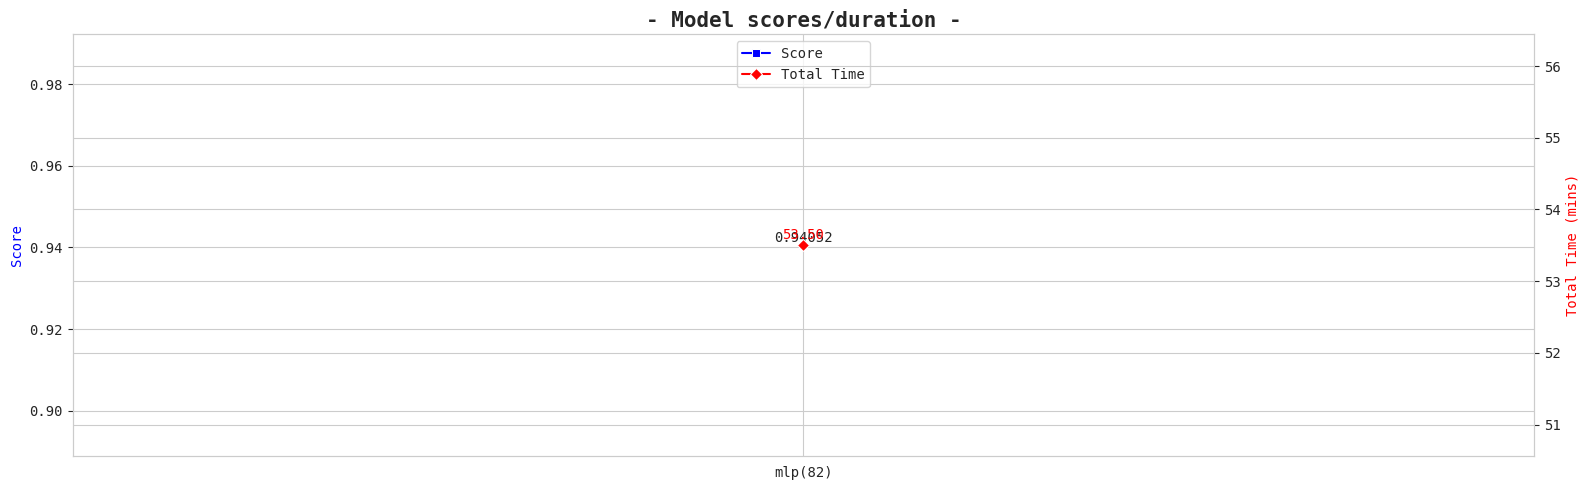

In [36]:
# Extract scores and times
all_scores = {k: v["score"] for k, v in all_predictions.items() if "score" in v}
all_times  = {k: v["total_time"] for k, v in all_predictions.items() if "total_time" in v}

fig, ax1 = plt.subplots(figsize=(16, 5))

# Create twin axis sharing the x-axis
ax2 = ax1.twinx()

# Plot scores on left y-axis (ax1)
sns.lineplot(
    x=range(len(all_scores)),
    y=list(all_scores.values()),
    marker="s",
    ax=ax1,
    color="b",
    label="Score",
    legend=False,
)
_add1 = 1e-7
for i, s1 in enumerate(all_scores.values()):
    ax1.text(float(i), s1 + _add1, f"{s1:.5f}", ha="center", va="bottom")

# Plot times on right y-axis (ax2)
sns.lineplot(
    x=range(len(all_times)),
    y=list(all_times.values()),
    marker="D",
    ax=ax2,
    color="r",
    label="Total Time",
    legend=False,
)
_add2 = 0.05
for i, s2 in enumerate(all_times.values()):
    ax2.text(float(i), s2 + _add2, f"{s2:.2f}", ha="center", va="bottom", color="red")

# Axis labels & X-ticks
ax1.set_xticks(range(len(all_scores)))
ax1.set_xticklabels(list(all_scores.keys()), rotation=0)
ax1.set_ylabel("Score", color="b")
ax2.set_ylabel("Total Time (mins)", color="r")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center")

plt.title("- Model scores/duration -", fontweight="semibold", fontsize=15)
plt.tight_layout()
plt.show()

mlp(82)_940524 saved!


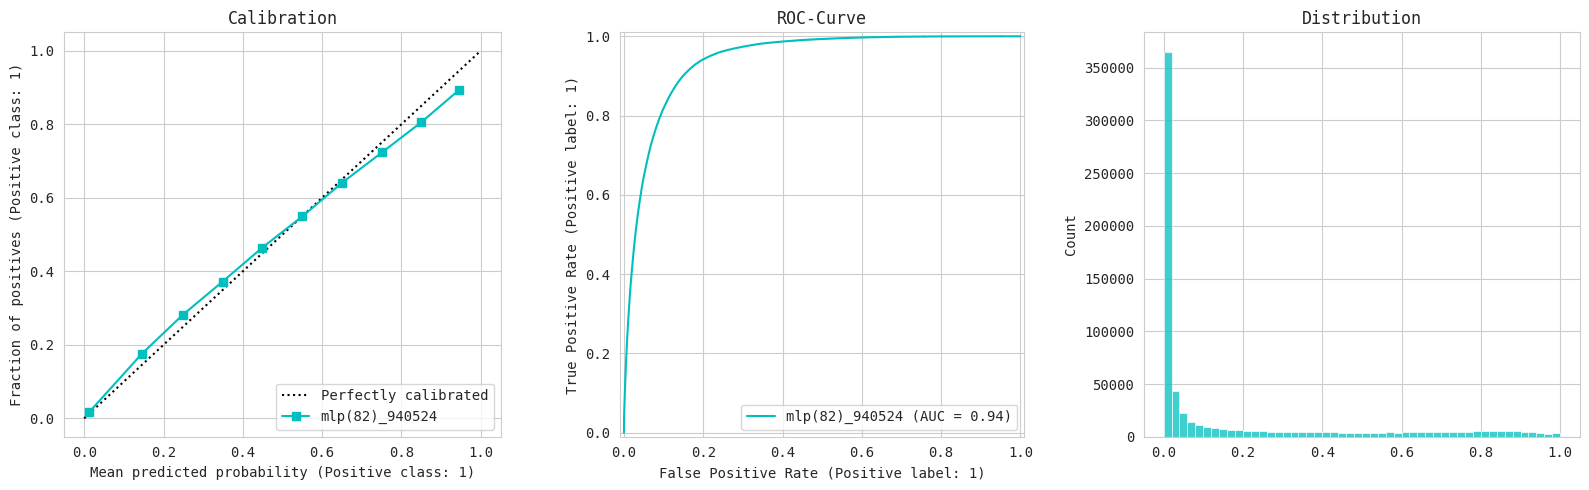

In [37]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_X[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title("Calibration")

            RocCurveDisplay.from_predictions(train_X[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title("ROC-Curve")

            sns.histplot(data_, ax=axs[2], bins=50)
            axs[2].set_title("Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [38]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submission[TARGET] = y
            submission.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n:>20} saved! {y.shape}")

            model_results[n[:-6]] = y

print()
model_results = pd.DataFrame(model_results)
model_results

      mlp(82)_940524 saved! (286571,)



,mlp(82)_
0,0.013704
1,0.015562
2,0.003566
3,0.003082
4,0.022041
...,...
286566,0.000188
286567,0.362361
286568,0.000213
286569,0.000127


In [39]:
# load_sample = np.load("/kaggle/working/test_knn_87175_.npy")
# load_sample[:5]

In [40]:
try:
    import shap
except:
    !uv pip install shap
    import shap

print(f"Shap version: {shap.__version__}")

Shap version: 0.51.0


In [41]:
# val_y
"""
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1]
 """

'\n[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,\n 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,\n 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,\n 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,\n 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,\n 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,\n 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1]\n '

Model pipeline features: 233


PermutationExplainer explainer: 151it [00:14,  4.10it/s]


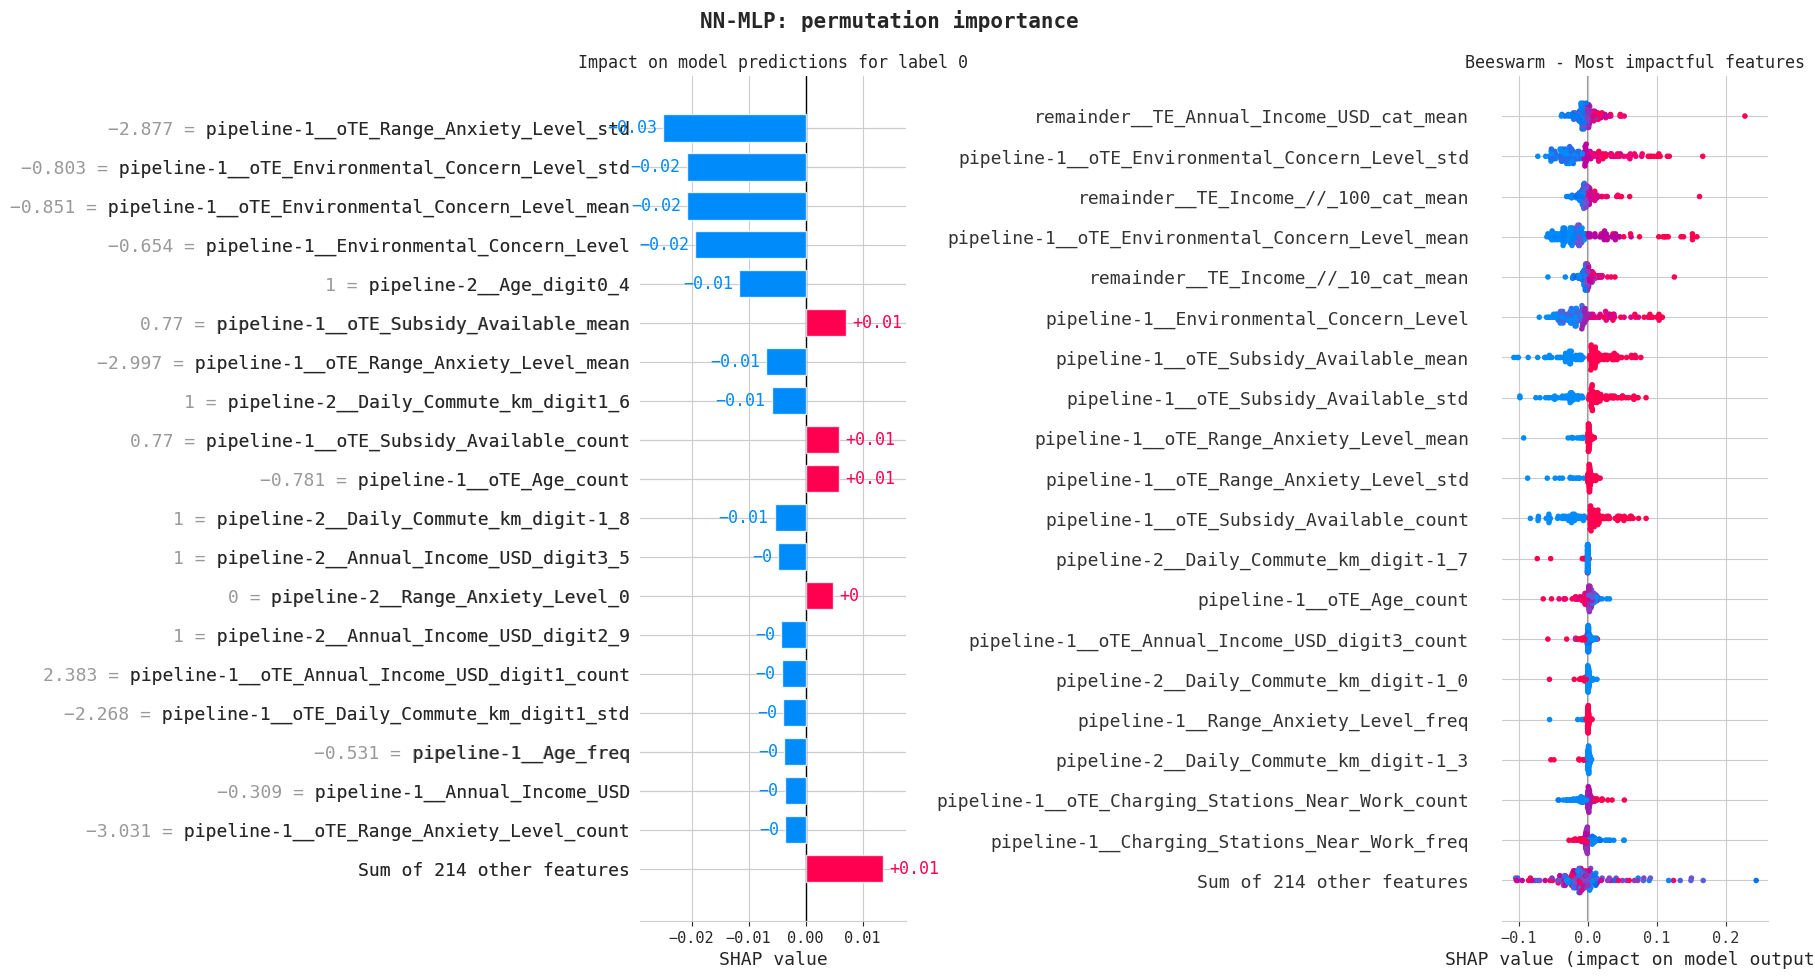

In [42]:
## -- SHAP values: Feature Importances--

models = [
    # ('LOGISTIC', all_predictions[list(all_predictions.keys())[0]]),
    # ('K-NEIGHBORS', all_predictions[list(all_predictions.keys())[1]]),
    ('NN-MLP', all_predictions[list(all_predictions.keys())[-1]]),
]

MAX = 20
_id = 30

for i, (n, m) in enumerate(models):
    feature_names = m["model"].named_steps['columntransformer'].get_feature_names_out()
    print(f"Model pipeline features: {len(feature_names)}")

    x_valid = m["model"][:-1].transform(m["val_data"][0])
    y_label = m["val_data"][1]

    rng = np.random.default_rng(seed=101)
    # Randomly select 100 rows without replacement
    val_x = rng.choice(x_valid, size=150, replace=False, axis=0)
    val_y = rng.choice(y_label, size=150, replace=False, axis=0)

    # model   = m["model"]
    # x_valid = m["val_data"][0]
    # y_label = m["val_data"][1]

    # val_x = x_valid.sample(n=max(150, 2*x_valid.shape[1]+1),random_state=9,ignore_index=True)
    # val_y = y_label.sample(n=max(150, 2*x_valid.shape[1]+1),random_state=9,ignore_index=True)
    
    ## -- Shap Explainer --
    def f(x):
        return m["model"][-1].predict_proba(x)[:, 1]
    explainer = shap.Explainer(f, val_x, feature_names=feature_names, seed=101)
    explanation = explainer(val_x)

    ## -- Bar plot --
    plt.subplot(121)
    shap.plots.bar(explanation[_id], max_display=MAX, show=False)
    plt.title(f"Impact on model predictions for label {val_y[_id]}")

    ## -- Beeswarm plot --
    plt.subplot(122)
    shap.plots.beeswarm(
        explanation, order=explanation.abs.max(0),
        plot_size=(18, 10), max_display=MAX, color_bar=False, show=False)
    plt.title("Beeswarm - Most impactful features")

    plt.suptitle(f"{n}: permutation importance", size=15, weight="semibold")
    plt.tight_layout(pad=1.5)
    plt.show()

    print()

In [43]:
# !rm -r /kaggle/working/

# HILLCLIMB

In [44]:
# try:
#     from hillclimbers import climb_hill, partial
# except:
#     %pip install -q -U hillclimbers
#     from hillclimbers import climb_hill, partial

# ## -- Load data --
# oof_df = pd.DataFrame()
# test_df = pd.DataFrame()

# print('Loading data: ', end='')
# for (root, dirs, files) in os.walk('/kaggle/working'):
#     for i, file in enumerate(sorted(files), 1):
#         if i%5 == 0: print(f'{i}%.. ', end='')
#         if file.endswith('.npy') and 'oof' in file:
#             oof_df = pd.concat([oof_df, pd.Series(np.load(os.path.join(root, file)),
#                                 name=file[4:-4])], axis=1)
#         elif file.endswith('.npy') and 'test' in file:
#             test_df = pd.concat([test_df, pd.Series(np.load(os.path.join(root, file)),
#                                 name=file[5:-4])], axis=1)

# print(CFG.YELLOW)
# print(f"OOF  loaded : {oof_df.shape}")
# print(f"TEST loaded : {test_df.shape}")

# display(oof_df.head())
# display(test_df.head())

In [45]:
# %%time

# trn = pd.read_csv(PATH+'train.csv').drop(columns=['id'])

# pred_hc, oof_hc = climb_hill(
#                                train = trn,
#                               target = TARGET,
#                          oof_pred_df = oof_df,
#                         test_pred_df = test_df,
#                            objective = 'maximize',
#                          eval_metric = partial(roc_auc_score),
#                     # negative_weights = True,
#                     return_oof_preds = True,
#                            precision = 0.01,
#                            plot_hill = True,
#                            plot_hist = True,
# )

In [46]:
# hc_auc = str(round(roc_auc_score(train[TARGET], oof_hc), 5)).split('.')[1]
# print(f"Hillclimb score: {hc_auc}")

# n = 'log-knn-mlp'
# np.save(f"oof_{n}_hillclimb_{hc_auc}.npy", oof_hc)
# np.save(f"test_{n}_hillclimb_{hc_auc}.npy", pred_hc)

# submit[TARGET] = pred_hc
# submit.to_csv(f"submit_{n}_hillclimb_{hc_auc}.csv", index=False)
# print(f"\n✅ Saved hillclimb ensemble!!!")

# submit.head(10)